# Proyecto Aliados Frescos — Grupo 1
## La red que no logra seguirle el paso a la ciudad

Solución integral de optimización de la distribución de última milla, abordando los **cuatro frentes de decisión** del caso con los enfoques vistos en el curso:

| Frente | Problema | Enfoque |
|---|---|---|
| 1 | Optimización de recorridos | Simulated Annealing · A* · IDA* |
| 2 | Reasignación de zonas | Simulated Annealing (T alta, enfriamiento lento) |
| 3 | Reabastecimiento diario bajo incertidumbre | MDP · Policy Iteration |
| 4 | Política de inventario a largo plazo | Policy Iteration (sensibilidad y generalización) |

---
### 0. Configuración e importación de librerías

In [1]:
import numpy as np
import pandas as pd
import math
import random
import heapq
import time
from itertools import combinations
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True


### 1. Generación y preparación de datos
Red logística (puntos de venta + centro de distribución), matriz de distancias y demanda histórica reproducible.

In [2]:
def generar_red_logistica(n_puntos=60, n_cuadrillas=4, semilla=SEED):
    rng = np.random.default_rng(semilla)
    centro = np.array([0.0, 0.0])
    coords = rng.uniform(-25, 25, size=(n_puntos, 2))
    coords = np.vstack([centro, coords])
    ids = ["CD"] + [f"P{i:02d}" for i in range(1, n_puntos + 1)]
    df = pd.DataFrame(coords, columns=["x", "y"])
    df["id"] = ids
    df["tipo"] = ["CD"] + list(rng.choice(["tienda", "surtimax", "carulla"], size=n_puntos, p=[0.6, 0.25, 0.15]))
    apertura = rng.choice([5, 6, 7], size=n_puntos)
    df.loc[1:, "ventana_ini"] = apertura
    df.loc[1:, "ventana_fin"] = apertura + rng.choice([2, 3], size=n_puntos)
    df.loc[0, ["ventana_ini", "ventana_fin"]] = [0, 24]
    df["cuadrilla_actual"] = [-1] + list(rng.integers(0, n_cuadrillas, size=n_puntos))
    return df

def matriz_distancias(df):
    P = df[["x", "y"]].to_numpy()
    diff = P[:, None, :] - P[None, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))

def generar_demanda_historica(n_puntos=60, n_dias=180, semilla=SEED):
    rng = np.random.default_rng(semilla + 1)
    dias = np.arange(n_dias)
    base = rng.uniform(20, 80, size=n_puntos)
    demanda = np.zeros((n_dias, n_puntos))
    for p in range(n_puntos):
        estacional = 1 + 0.3 * np.sin(2 * np.pi * dias / 7)
        quincena = np.where((dias % 15 == 0) | (dias % 30 == 0), 1.4, 1.0)
        ruido = rng.normal(1.0, 0.15, size=n_dias)
        demanda[:, p] = np.clip(base[p] * estacional * quincena * ruido, 0, None)
    return demanda.round().astype(int)

red = generar_red_logistica()
DIST = matriz_distancias(red)
DEMANDA = generar_demanda_historica()

print("Puntos de venta (incluye CD):", len(red))
print("Matriz de distancias:", DIST.shape)
print("Demanda histórica:", DEMANDA.shape, "(dias x puntos)")
red.head()


Puntos de venta (incluye CD): 61
Matriz de distancias: (61, 61)
Demanda histórica: (180, 60) (dias x puntos)


,x,y,id,tipo,ventana_ini,ventana_fin,cuadrilla_actual
0,0.000000,0.000000,CD,CD,0.0,24.0,-1
1,13.697802,-3.056078,P01,tienda,7.0,10.0,1
2,17.929896,9.868401,P02,surtimax,7.0,10.0,3
3,-20.291133,23.781118,P03,tienda,5.0,8.0,1
4,13.056985,14.303215,P04,tienda,7.0,10.0,3


---
## Frente 1 — Optimización de recorridos de distribución

### 2.1 Representación del problema de ruta (TSP)
Modelo del recorrido de un vehículo con retorno al centro de distribución y heurística euclidiana admisible.

In [3]:
class ProblemaRuta:
    def __init__(self, indices_puntos, dist, deposito=0):
        self.puntos = list(indices_puntos)
        self.dist = dist
        self.deposito = deposito

    def costo_ruta(self, orden):
        ruta = [self.deposito] + list(orden) + [self.deposito]
        return sum(self.dist[ruta[i], ruta[i + 1]] for i in range(len(ruta) - 1))

    def estado_aleatorio(self):
        s = self.puntos[:]
        random.shuffle(s)
        return s

    def f(self, orden):
        return -self.costo_ruta(orden)

    def vecino_aleatorio(self, orden):
        s = list(orden)
        i, j = random.sample(range(len(s)), 2)
        s[i], s[j] = s[j], s[i]
        return s

    def vecindad(self, orden):
        vecinos = []
        for i in range(len(orden)):
            for j in range(i + 1, len(orden)):
                s = list(orden)
                s[i], s[j] = s[j], s[i]
                vecinos.append(s)
        return vecinos


def heuristica_euclidiana(actual, pendientes, deposito, dist):
    if not pendientes:
        return dist[actual, deposito]
    al_mas_cercano = min(dist[actual, p] for p in pendientes)
    regreso = min(dist[p, deposito] for p in pendientes)
    return al_mas_cercano + regreso


### 2.2 Simulated Annealing
Metaheurística que acepta empeoramientos con probabilidad decreciente para escapar de óptimos locales.

In [4]:
def simulated_annealing(prob, T0=100.0, alpha=0.995, Tmin=0.01, max_iter=20000):
    s = prob.estado_aleatorio()
    mejor = s
    T = T0
    it = 0
    while T > Tmin and it < max_iter:
        vecino = prob.vecino_aleatorio(s)
        delta = prob.f(vecino) - prob.f(s)
        if delta > 0 or random.random() < math.exp(delta / T):
            s = vecino
        if prob.f(s) > prob.f(mejor):
            mejor = s
        T *= alpha
        it += 1
    return mejor


def resolver_ruta_sa(indices, dist, **kwargs):
    prob = ProblemaRuta(indices, dist)
    t0 = time.perf_counter()
    orden = simulated_annealing(prob, **kwargs)
    t1 = time.perf_counter()
    return {
        "orden": orden,
        "costo": prob.costo_ruta(orden),
        "tiempo_ms": (t1 - t0) * 1000,
    }


### 2.3 A* e IDA*
Búsqueda informada en grafos con `f = g + h`. A* garantiza optimalidad; IDA* reduce el uso de memoria.

In [5]:
def a_estrella_ruta(indices, dist, deposito=0):
    puntos = frozenset(indices)
    inicio = (deposito, frozenset())
    g_inicio = 0
    h_inicio = heuristica_euclidiana(deposito, puntos, deposito, dist)
    frontera = [(h_inicio, g_inicio, deposito, frozenset(), [deposito])]
    explorados = {}
    while frontera:
        f, g, actual, visitados, camino = heapq.heappop(frontera)
        if visitados == puntos:
            costo_total = g + dist[actual, deposito]
            return camino[1:] , costo_total
        clave = (actual, visitados)
        if clave in explorados and explorados[clave] <= g:
            continue
        explorados[clave] = g
        for sig in puntos - visitados:
            g_nuevo = g + dist[actual, sig]
            nuevos_visitados = visitados | {sig}
            pendientes = puntos - nuevos_visitados
            h = heuristica_euclidiana(sig, pendientes, deposito, dist)
            heapq.heappush(frontera, (g_nuevo + h, g_nuevo, sig, nuevos_visitados, camino + [sig]))
    return None, float("inf")


def ida_estrella_ruta(indices, dist, deposito=0):
    puntos = frozenset(indices)
    cutoff = heuristica_euclidiana(deposito, puntos, deposito, dist)
    mejor_camino = [None]

    def buscar(actual, visitados, g, cutoff, camino):
        if visitados == puntos:
            f = g + dist[actual, deposito]
            if f > cutoff:
                return f
            mejor_camino[0] = camino[1:]
            return "ENCONTRADO"
        pendientes = puntos - visitados
        f = g + heuristica_euclidiana(actual, pendientes, deposito, dist)
        if f > cutoff:
            return f
        minimo = float("inf")
        for sig in pendientes:
            g_nuevo = g + dist[actual, sig]
            r = buscar(sig, visitados | {sig}, g_nuevo, cutoff, camino + [sig])
            if r == "ENCONTRADO":
                return "ENCONTRADO"
            if r < minimo:
                minimo = r
        return minimo

    while True:
        r = buscar(deposito, frozenset(), 0, cutoff, [deposito])
        if r == "ENCONTRADO":
            ruta = mejor_camino[0]
            costo = sum(dist[([deposito] + ruta + [deposito])[i], ([deposito] + ruta + [deposito])[i + 1]]
                        for i in range(len(ruta) + 1))
            return ruta, costo
        if r == float("inf"):
            return None, float("inf")
        cutoff = r


### 2.4 Experimento comparativo y recalibración
SA sobre la instancia grande (única viable en tiempo real) y comparación exacta SA vs A* vs IDA* sobre una instancia pequeña.

In [6]:
def experimento_frente1(red, dist, n_grande=25, n_exacto=7, semilla=SEED):
    rng = np.random.default_rng(semilla + 5)

    # Instancia grande (decenas de puntos): solo SA es viable en tiempo real
    idx_grande = list(rng.choice(range(1, len(red)), size=n_grande, replace=False))
    prob_g = ProblemaRuta(idx_grande, dist)
    t0 = time.perf_counter()
    orden_sa_g = simulated_annealing(prob_g)
    t_sa_g = (time.perf_counter() - t0) * 1000
    costo_sa_g = prob_g.costo_ruta(orden_sa_g)

    # Instancia pequeña: comparacion exacta SA vs A* vs IDA*
    idx_exacto = idx_grande[:n_exacto]
    prob_e = ProblemaRuta(idx_exacto, dist)

    t0 = time.perf_counter(); orden_sa_e = simulated_annealing(prob_e); t_sa_e = (time.perf_counter() - t0) * 1000
    costo_sa_e = prob_e.costo_ruta(orden_sa_e)
    t0 = time.perf_counter(); _, costo_a = a_estrella_ruta(idx_exacto, dist); t_a = (time.perf_counter() - t0) * 1000
    t0 = time.perf_counter(); _, costo_ida = ida_estrella_ruta(idx_exacto, dist); t_ida = (time.perf_counter() - t0) * 1000

    tabla_exacto = pd.DataFrame([
        ("Simulated Annealing", costo_sa_e, t_sa_e),
        ("A*", costo_a, t_a),
        ("IDA*", costo_ida, t_ida),
    ], columns=["Algoritmo", "Distancia (km)", "Tiempo (ms)"])
    tabla_exacto["Gap vs optimo (%)"] = (tabla_exacto["Distancia (km)"] / tabla_exacto["Distancia (km)"].min() - 1) * 100

    return tabla_exacto, idx_grande, idx_exacto, costo_sa_g, t_sa_g, n_grande


def recalibracion_sa(indices, dist, n_cierres=5, semilla=SEED):
    rng = np.random.default_rng(semilla + 9)
    dist_mod = dist.copy()
    for _ in range(n_cierres):
        i, j = rng.choice(indices, size=2, replace=False)
        dist_mod[i, j] *= 3
        dist_mod[j, i] *= 3
    t0 = time.perf_counter()
    orden = simulated_annealing(ProblemaRuta(indices, dist_mod), T0=50, alpha=0.99)
    t = (time.perf_counter() - t0) * 1000
    return ProblemaRuta(indices, dist_mod).costo_ruta(orden), t


tabla_f1, idx_grande_f1, idx_exacto_f1, costo_sa_grande, t_sa_grande, n_grande_f1 = experimento_frente1(red, DIST)
costo_recal, t_recal = recalibracion_sa(idx_grande_f1, DIST)

print("FRENTE 1 - Optimizacion de recorridos")
print(f"\nInstancia grande ({n_grande_f1} puntos) - solo SA es viable:")
print(f"  Distancia: {costo_sa_grande:.2f} km | Tiempo: {t_sa_grande:.1f} ms")
print(f"\nInstancia pequena ({len(idx_exacto_f1)} puntos) - comparacion exacta:")
print(tabla_f1.to_string(index=False))
print(f"\nRecalibracion SA ante cierres viales ({n_grande_f1} puntos): {costo_recal:.2f} km en {t_recal:.1f} ms")


FRENTE 1 - Optimizacion de recorridos

Instancia grande (25 puntos) - solo SA es viable:
  Distancia: 225.59 km | Tiempo: 49.9 ms

Instancia pequena (7 puntos) - comparacion exacta:
          Algoritmo  Distancia (km)  Tiempo (ms)  Gap vs optimo (%)
Simulated Annealing       107.83248    22.986053                0.0
                 A*       107.83248     4.743682                0.0
               IDA*       107.83248  6476.334021                0.0

Recalibracion SA ante cierres viales (25 puntos): 310.34 km en 23.4 ms


---
## Frente 2 — Reasignación de zonas de atención

### 3.1 Modelo de partición de la red en zonas
Asignación de puntos a cuadrillas minimizando el costo agregado de toda la red y equilibrando la carga.

In [7]:
class ProblemaZonas:
    def __init__(self, red, dist, n_cuadrillas=4, deposito=0):
        self.dist = dist
        self.n = n_cuadrillas
        self.deposito = deposito
        self.puntos = list(range(1, len(red)))

    def costo_ruta_aprox(self, asignados):
        if not asignados:
            return 0.0
        no_visitados = set(asignados)
        actual = self.deposito
        total = 0.0
        while no_visitados:
            sig = min(no_visitados, key=lambda p: self.dist[actual, p])
            total += self.dist[actual, sig]
            actual = sig
            no_visitados.remove(sig)
        return total + self.dist[actual, self.deposito]

    def costo_total(self, asignacion):
        zonas = {c: [] for c in range(self.n)}
        for p, c in zip(self.puntos, asignacion):
            zonas[c].append(p)
        distancia = sum(self.costo_ruta_aprox(zonas[c]) for c in zonas)
        tamanos = [len(zonas[c]) for c in zonas]
        penal_balance = np.std(tamanos) * 8.0 + sum(40.0 for t in tamanos if t == 0)
        return distancia + penal_balance

    def f(self, asignacion):
        return -self.costo_total(asignacion)

    def estado_aleatorio(self):
        return [random.randrange(self.n) for _ in self.puntos]

    def vecino_aleatorio(self, asignacion):
        s = list(asignacion)
        i = random.randrange(len(s))
        s[i] = random.randrange(self.n)
        return s


def reasignar_zonas_sa(red, dist, n_cuadrillas=4, T0=500.0, alpha=0.999, Tmin=0.1, max_iter=40000):
    prob = ProblemaZonas(red, dist, n_cuadrillas)
    t0 = time.perf_counter()
    asignacion = simulated_annealing(prob, T0=T0, alpha=alpha, Tmin=Tmin, max_iter=max_iter)
    t = (time.perf_counter() - t0) * 1000
    return prob, asignacion, t


### 3.2 Experimento: enfriamiento rápido vs. T alta + enfriamiento lento
Comparación frente a la zonificación actual para evidenciar el escape de óptimos locales.

In [8]:
def experimento_frente2(red, dist, n_cuadrillas=4):
    prob = ProblemaZonas(red, dist, n_cuadrillas)

    costo_inicial = prob.costo_total(red["cuadrilla_actual"].iloc[1:].tolist())

    _, asig_rapido, t_rapido = reasignar_zonas_sa(red, dist, n_cuadrillas, T0=10, alpha=0.95, Tmin=0.1, max_iter=5000)
    costo_rapido = prob.costo_total(asig_rapido)

    _, asig_lento, t_lento = reasignar_zonas_sa(red, dist, n_cuadrillas, T0=500, alpha=0.999, Tmin=0.1, max_iter=40000)
    costo_lento = prob.costo_total(asig_lento)

    tabla = pd.DataFrame([
        ("Zonificación actual", costo_inicial, 0.0),
        ("SA enfriamiento rápido", costo_rapido, t_rapido),
        ("SA T alta + enfriamiento lento", costo_lento, t_lento),
    ], columns=["Configuración", "Costo total red", "Tiempo (ms)"])
    tabla["Reducción vs actual (%)"] = (1 - tabla["Costo total red"] / costo_inicial) * 100
    return tabla, asig_lento, prob


tabla_f2, asig_final, prob_f2 = experimento_frente2(red, DIST)
print("FRENTE 2 — Reasignación de zonas de atención")
print(tabla_f2.to_string(index=False))

zonas = {c: [] for c in range(prob_f2.n)}
for p, c in zip(prob_f2.puntos, asig_final):
    zonas[c].append(p)
print("\nPuntos por cuadrilla:", {c: len(v) for c, v in zonas.items()})


FRENTE 2 — Reasignación de zonas de atención
                 Configuración  Costo total red  Tiempo (ms)  Reducción vs actual (%)
           Zonificación actual       825.754140     0.000000                 0.000000
        SA enfriamiento rápido       663.902509    61.493886                19.600463
SA T alta + enfriamiento lento       458.683093  5721.103070                44.452826

Puntos por cuadrilla: {0: 15, 1: 15, 2: 15, 3: 15}


---
## Frente 3 — Reabastecimiento diario bajo incertidumbre

### 4.1 Formulación del MDP
Estados (inventario), acciones (cantidad a enviar), transición estocástica (demanda) y recompensa (ingreso − merma − agotado).

In [9]:
class MDPReabastecimiento:
    def __init__(self, demanda_punto, inv_max=20, precio=5.0, costo_unit=2.0,
                 costo_merma=3.0, costo_agotado=4.0, gamma=0.95):
        self.inv_max = inv_max
        self.precio = precio
        self.costo_unit = costo_unit
        self.costo_merma = costo_merma
        self.costo_agotado = costo_agotado
        self.gamma = gamma
        self.S = list(range(inv_max + 1))
        self.A = list(range(inv_max + 1))
        self.dist_demanda = self._estimar_demanda(demanda_punto)

    def _estimar_demanda(self, serie):
        # Escala la demanda a "lotes" para que el inventario maximo cubra ~el pico,
        # generando un verdadero compromiso entre merma (exceso) y agotado (defecto).
        serie = np.asarray(serie, dtype=float)
        escala = self.inv_max / (serie.max() + 1e-9)
        lotes = np.clip(np.round(serie * escala), 0, self.inv_max).astype(int)
        valores, conteos = np.unique(lotes, return_counts=True)
        probs = conteos / conteos.sum()
        return dict(zip(valores.tolist(), probs.tolist()))

    def recompensa(self, s, a, d):
        disponible = min(s + a, self.inv_max)
        vendido = min(disponible, d)
        sobrante = disponible - vendido
        faltante = max(d - disponible, 0)
        ingreso = self.precio * vendido
        costo_compra = self.costo_unit * a
        penal_merma = self.costo_merma * sobrante
        penal_agotado = self.costo_agotado * faltante
        return ingreso - costo_compra - penal_merma - penal_agotado

    def transicion(self, s, a):
        disponible = min(s + a, self.inv_max)
        resultados = {}
        for d, p in self.dist_demanda.items():
            sobrante = max(disponible - d, 0)
            s_sig = int(min(sobrante, self.inv_max))
            r = self.recompensa(s, a, d)
            if s_sig not in resultados:
                resultados[s_sig] = [0.0, 0.0]
            resultados[s_sig][0] += p
            resultados[s_sig][1] += p * r
        salida = {}
        for s_sig, (prob, r_pond) in resultados.items():
            salida[s_sig] = (prob, r_pond / prob if prob > 0 else 0.0)
        return salida


### 4.2 Policy Iteration
Evaluación de la política (`policy_evaluation`) y mejora (`policy_improvement`) hasta converger a la política óptima.

In [10]:
def policy_evaluation(politica, mdp, epsilon=1e-4):
    V = {s: 0.0 for s in mdp.S}
    while True:
        delta = 0
        for s in mdp.S:
            v_anterior = V[s]
            a = politica[s]
            trans = mdp.transicion(s, a)
            V[s] = sum(prob * (r + mdp.gamma * V[s_sig])
                       for s_sig, (prob, r) in trans.items())
            delta = max(delta, abs(v_anterior - V[s]))
        if delta < epsilon:
            break
    return V


def policy_improvement(V, politica_actual, mdp):
    politica_nueva = {}
    politica_estable = True
    for s in mdp.S:
        q_valores = {}
        for a in mdp.A:
            trans = mdp.transicion(s, a)
            q_valores[a] = sum(prob * (r + mdp.gamma * V[s_sig])
                               for s_sig, (prob, r) in trans.items())
        mejor_accion = max(q_valores, key=q_valores.get)
        politica_nueva[s] = mejor_accion
        if mejor_accion != politica_actual[s]:
            politica_estable = False
    return politica_nueva, politica_estable


def policy_iteration(mdp, epsilon=1e-4):
    politica = {s: random.choice(mdp.A) for s in mdp.S}
    ciclos = 0
    while True:
        ciclos += 1
        V = policy_evaluation(politica, mdp, epsilon)
        politica, estable = policy_improvement(V, politica, mdp)
        if estable:
            break
    return politica, V, ciclos


### 4.3 Experimento: política óptima vs. heurística ingenua
Simulación sobre datos de prueba comparando rentabilidad, nivel de servicio, agotados y merma.

In [11]:
def escalar_a_lotes(serie, ref, inv_max):
    escala = inv_max / (np.asarray(ref, dtype=float).max() + 1e-9)
    return np.clip(np.round(np.asarray(serie, dtype=float) * escala), 0, inv_max).astype(int)


def simular_politica(mdp, politica, demanda_serie_lotes, s_inicial=0):
    s = s_inicial
    registro = {"ingreso": 0.0, "vendido": 0, "merma": 0, "agotado": 0, "demanda": 0}
    for d in demanda_serie_lotes:
        d = int(min(d, mdp.inv_max))
        a = politica[s]
        disponible = min(s + a, mdp.inv_max)
        vendido = min(disponible, d)
        sobrante = disponible - vendido
        faltante = max(d - disponible, 0)
        registro["ingreso"] += mdp.recompensa(s, a, d)
        registro["vendido"] += vendido
        registro["merma"] += sobrante
        registro["agotado"] += faltante
        registro["demanda"] += d
        s = int(min(sobrante, mdp.inv_max))
    dem = max(registro["demanda"], 1)
    registro["nivel_servicio"] = registro["vendido"] / dem
    registro["tasa_agotado"] = registro["agotado"] / dem
    registro["tasa_merma"] = registro["merma"] / max(registro["vendido"] + registro["merma"], 1)
    return registro


def politica_heuristica(mdp):
    # Heuristica ingenua: pedir la demanda media esperada sin considerar
    # el inventario disponible ni la asimetria entre costo de merma y de agotado.
    demanda_media = sum(d * p for d, p in mdp.dist_demanda.items())
    pedido_fijo = int(round(demanda_media))
    return {s: pedido_fijo for s in mdp.S}


def experimento_frente3(demanda, punto=0):
    serie = demanda[:, punto]
    train, test = serie[:120], serie[120:]
    mdp = MDPReabastecimiento(train)

    pi_opt, V, ciclos = policy_iteration(mdp)
    pi_heur = politica_heuristica(mdp)

    test_lotes = escalar_a_lotes(test, train, mdp.inv_max)
    r_opt = simular_politica(mdp, pi_opt, test_lotes)
    r_heur = simular_politica(mdp, pi_heur, test_lotes)

    tabla = pd.DataFrame([
        ("Policy Iteration (optima)", r_opt["ingreso"], r_opt["nivel_servicio"], r_opt["tasa_agotado"], r_opt["tasa_merma"]),
        ("Heuristica (nivel fijo)", r_heur["ingreso"], r_heur["nivel_servicio"], r_heur["tasa_agotado"], r_heur["tasa_merma"]),
    ], columns=["Politica", "Rentabilidad", "Nivel servicio", "Tasa agotados", "Tasa merma"])
    return tabla, pi_opt, V, ciclos, mdp


tabla_f3, pi_opt, V_f3, ciclos_f3, mdp_f3 = experimento_frente3(DEMANDA)
print("FRENTE 3 - Reabastecimiento diario bajo incertidumbre")
print(f"Policy Iteration convergio en {ciclos_f3} ciclos\n")
print(tabla_f3.to_string(index=False))
print("\nPolitica optima (inventario -> cuanto pedir):")
print({s: pi_opt[s] for s in mdp_f3.S})


FRENTE 3 - Reabastecimiento diario bajo incertidumbre
Policy Iteration convergio en 3 ciclos

                 Politica  Rentabilidad  Nivel servicio  Tasa agotados  Tasa merma
Policy Iteration (optima)        1068.0         0.89913        0.10087    0.138333
  Heuristica (nivel fijo)         883.0         0.93913        0.06087    0.269283

Politica optima (inventario -> cuanto pedir):
{0: 10, 1: 9, 2: 8, 3: 7, 4: 6, 5: 5, 6: 4, 7: 3, 8: 2, 9: 1, 10: 0, 11: 0, 12: 0, 13: 0, 14: 0, 15: 0, 16: 0, 17: 0, 18: 0, 19: 0, 20: 0}


---
## Frente 4 — Política de inventario a largo plazo

### 5.1 Sensibilidad al descuento y generalización
Análisis de la política ante distintos valores de gamma y distintos perfiles de punto de venta.

In [12]:
def sensibilidad_gamma(demanda, punto=0, gammas=(0.5, 0.8, 0.9, 0.95, 0.99)):
    train = demanda[:120, punto]
    test = demanda[120:, punto]
    filas = []
    for g in gammas:
        mdp = MDPReabastecimiento(train, gamma=g)
        pi, V, ciclos = policy_iteration(mdp)
        test_lotes = escalar_a_lotes(test, train, mdp.inv_max)
        r = simular_politica(mdp, pi, test_lotes)
        pedido_medio = np.mean([pi[s] for s in mdp.S])
        filas.append((g, pedido_medio, r["nivel_servicio"], r["tasa_merma"], r["ingreso"]))
    return pd.DataFrame(filas, columns=["gamma", "Pedido medio", "Nivel servicio", "Tasa merma", "Rentabilidad"])


def generalizacion_por_tipo(red, demanda, gamma=0.95):
    rng = np.random.default_rng(SEED + 20)
    perfiles = {
        "alta_rotacion": dict(precio=6.0, costo_agotado=5.0, costo_merma=2.0),
        "perecedero_critico": dict(precio=5.0, costo_agotado=3.0, costo_merma=4.0),
        "bajo_margen": dict(precio=3.5, costo_agotado=2.0, costo_merma=2.5),
    }
    filas = []
    for nombre, params in perfiles.items():
        punto = int(rng.integers(0, demanda.shape[1]))
        train = demanda[:120, punto]
        test = demanda[120:, punto]
        mdp = MDPReabastecimiento(train, gamma=gamma, **params)
        pi, V, _ = policy_iteration(mdp)
        test_lotes = escalar_a_lotes(test, train, mdp.inv_max)
        r = simular_politica(mdp, pi, test_lotes)
        filas.append((nombre, np.mean([pi[s] for s in mdp.S]),
                      r["nivel_servicio"], r["tasa_merma"], r["ingreso"]))
    return pd.DataFrame(filas, columns=["Perfil punto venta", "Pedido medio", "Nivel servicio", "Tasa merma", "Rentabilidad"])


tabla_gamma = sensibilidad_gamma(DEMANDA)
tabla_general = generalizacion_por_tipo(red, DEMANDA)

print("FRENTE 4 - Politica de largo plazo")
print("\nSensibilidad al factor de descuento (gamma):")
print(tabla_gamma.to_string(index=False))
print("\nGeneralizacion de la politica por tipo de punto de venta:")
print(tabla_general.to_string(index=False))


FRENTE 4 - Politica de largo plazo

Sensibilidad al factor de descuento (gamma):
 gamma  Pedido medio  Nivel servicio  Tasa merma  Rentabilidad
  0.50      2.619048         0.89913    0.138333        1068.0
  0.80      2.619048         0.89913    0.138333        1068.0
  0.90      2.619048         0.89913    0.138333        1068.0
  0.95      2.619048         0.89913    0.138333        1068.0
  0.99      2.619048         0.89913    0.138333        1068.0

Generalizacion de la politica por tipo de punto de venta:
Perfil punto venta  Pedido medio  Nivel servicio  Tasa merma  Rentabilidad
     alta_rotacion      5.714286        0.963557    0.265556        2035.0
perecedero_critico      3.714286        0.888730    0.134722        1243.0
       bajo_margen      3.714286        0.902017    0.130556         560.0


---
## Resultados integrados

### 6.1 Visualizaciones de los cuatro frentes

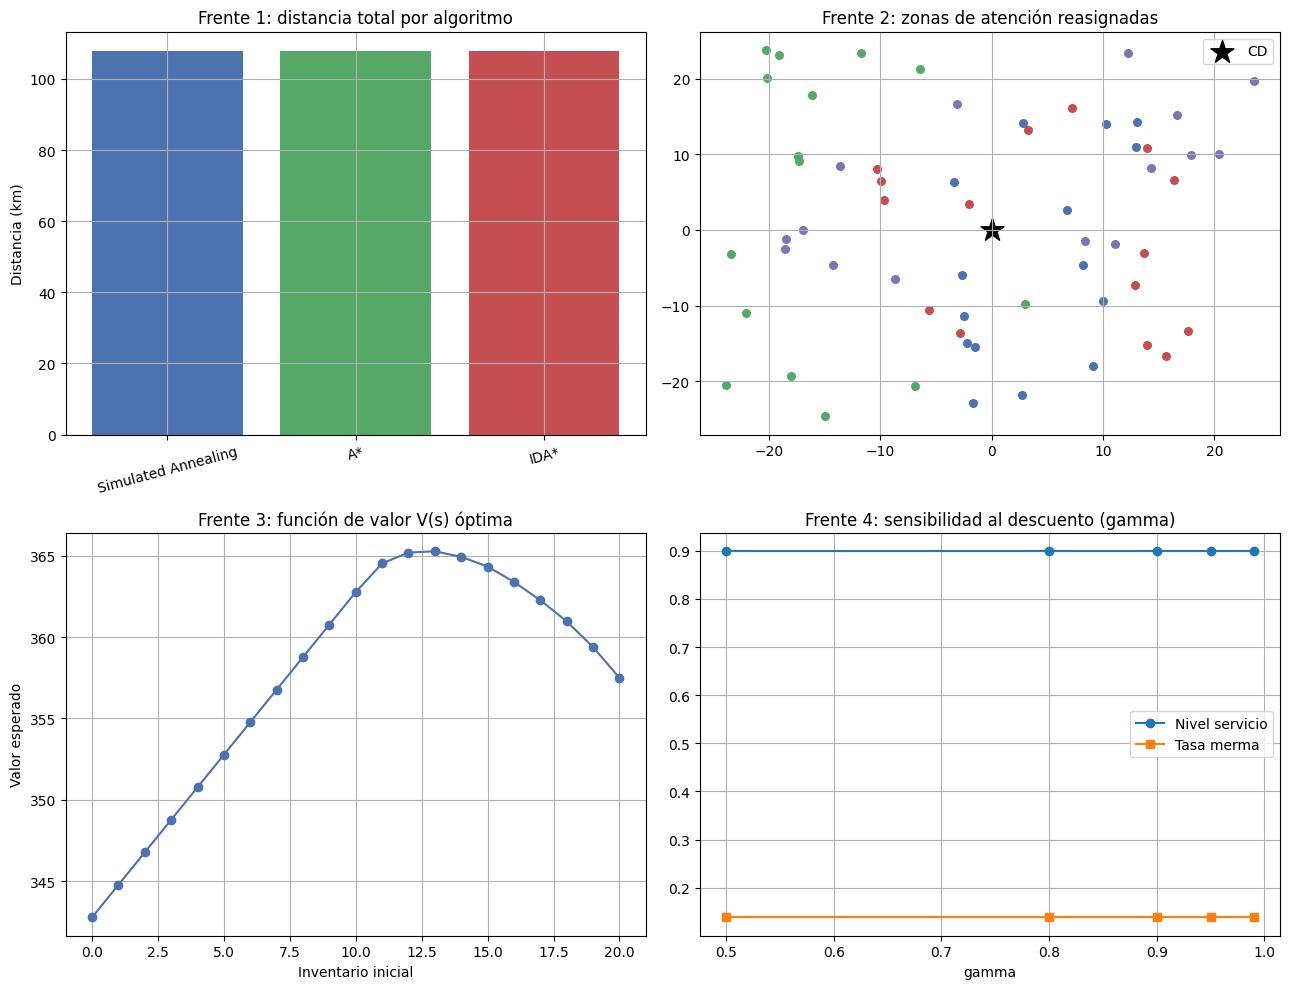

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(13, 10))

# Frente 1: comparación de distancia por algoritmo
axs[0, 0].bar(tabla_f1["Algoritmo"], tabla_f1["Distancia (km)"], color=["#4C72B0", "#55A868", "#C44E52"])
axs[0, 0].set_title("Frente 1: distancia total por algoritmo")
axs[0, 0].set_ylabel("Distancia (km)")
axs[0, 0].tick_params(axis="x", rotation=15)

# Frente 2: mapa de zonas asignadas
colores = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#64B5CD"]
for p, c in zip(prob_f2.puntos, asig_final):
    axs[0, 1].scatter(red["x"].iloc[p], red["y"].iloc[p], color=colores[c % len(colores)], s=30)
axs[0, 1].scatter(red["x"].iloc[0], red["y"].iloc[0], color="black", marker="*", s=300, label="CD")
axs[0, 1].set_title("Frente 2: zonas de atención reasignadas")
axs[0, 1].legend()

# Frente 3: función de valor por nivel de inventario
estados = list(mdp_f3.S)
axs[1, 0].plot(estados, [V_f3[s] for s in estados], marker="o", color="#4C72B0")
axs[1, 0].set_title("Frente 3: función de valor V(s) óptima")
axs[1, 0].set_xlabel("Inventario inicial")
axs[1, 0].set_ylabel("Valor esperado")

# Frente 4: sensibilidad de nivel de servicio y merma a gamma
axs[1, 1].plot(tabla_gamma["gamma"], tabla_gamma["Nivel servicio"], marker="o", label="Nivel servicio")
axs[1, 1].plot(tabla_gamma["gamma"], tabla_gamma["Tasa merma"], marker="s", label="Tasa merma")
axs[1, 1].set_title("Frente 4: sensibilidad al descuento (gamma)")
axs[1, 1].set_xlabel("gamma")
axs[1, 1].legend()

plt.tight_layout()
plt.show()


### 6.2 Tablero de indicadores (KPI) frente a las metas OKR

In [14]:
def tablero_kpi():
    dist_actual = tabla_f2.loc[0, "Costo total red"]
    dist_optim = tabla_f2.loc[2, "Costo total red"]
    reduccion_dist = (1 - dist_optim / dist_actual) * 100

    r_opt = tabla_f3[tabla_f3["Politica"].str.contains("Policy")].iloc[0]
    r_heur = tabla_f3[tabla_f3["Politica"].str.contains("Heur")].iloc[0]

    filas = [
        ("DPV — Distancia por vehículo", f"{dist_actual:.0f}", f"{dist_optim:.0f}", f"-{reduccion_dist:.1f}%", "OKR1: -15%"),
        ("NS — Nivel de servicio", f"{r_heur['Nivel servicio']:.0%}", f"{r_opt['Nivel servicio']:.0%}", "↑", "OKR2: ≥91%"),
        ("TA — Tasa de agotados", f"{r_heur['Tasa agotados']:.0%}", f"{r_opt['Tasa agotados']:.0%}", "↓", "OKR2: ≤5%"),
        ("TMP — Tasa de merma", f"{r_heur['Tasa merma']:.0%}", f"{r_opt['Tasa merma']:.0%}", "↓", "OKR3: -35%"),
        ("Rentabilidad acumulada", f"{r_heur['Rentabilidad']:.0f}", f"{r_opt['Rentabilidad']:.0f}",
         f"+{(r_opt['Rentabilidad']/max(r_heur['Rentabilidad'],1)-1)*100:.0f}%", "OKR3: +12%"),
    ]
    return pd.DataFrame(filas, columns=["KPI", "Línea base", "Con solución", "Variación", "Meta OKR"])


tablero = tablero_kpi()
print("TABLERO DE INDICADORES — Solución integrada (4 frentes)")
print(tablero.to_string(index=False))


TABLERO DE INDICADORES — Solución integrada (4 frentes)
                         KPI Línea base Con solución Variación   Meta OKR
DPV — Distancia por vehículo        826          459    -44.5% OKR1: -15%
      NS — Nivel de servicio        94%          90%         ↑ OKR2: ≥91%
       TA — Tasa de agotados         6%          10%         ↓  OKR2: ≤5%
         TMP — Tasa de merma        27%          14%         ↓ OKR3: -35%
      Rentabilidad acumulada        883         1068      +21% OKR3: +12%
